## test_nuradio_single.py

### Basic Workflow
1. create a wrapper with a constructor\
`reader = NuRadioRecoReader(det, filt_settings)`
2. Read event \
`evt = reader.read_data_event_with_noise(filename, Tnoise)`
3. Apply analysis

### Event Object
**Station** object
- obtained by an iterator `evt.get_stations()`
- methods include `get_id()`, `iter_channels()`, `get_sim_station()`

**Channel** object
- Iterated in `station.iter_channels()`
- Contains traces
- Methods include: `get_trace()`, `get_times()`, `get_sampling_rate()`, `get_id()`

**sim_station** object
- Obtained by `station.get_sim_station()`
- Contains "true" electric field
- Methods include: `get_electric_fields()` returning an array(?) of ElectricField object

**EField** object
- `get_trace()` returns Ex, Ey, Ez components

### Functions defined
**__init__(self, det, filt_settings, sky_model="gsm2008")**\
Wrapper module to read in NuRadioReco events from CoREAS simulations with applied antenna response, bandpass, and noise, and optionally simulating the trigger and signal reconstruction. \
This can be used to read events to be applied to any reconstruction, such as a fluence-based reconstruction.

*Parameters*:
- det: NuRadioReco.detector.Detector object\
&emsp; The detector object containing the station and antenna information.\
- filt_settings: dict\
&emsp; The settings for the bandpass filter to be applied to the electric field and voltage traces.\
&emsp; Example: `filter_settings = {
    "passband": [30 * units.MHz, 80 * units.MHz],
    "filter_type": "butter",
    "order": 10,
}`

**__initialize_modules(self, sky_model="gsm2008")**\
Initializes all required modules from NuRadio. This includes:
- bandpass filter in Efield level
- Signal reconstruction from Voltage to Electric Field
- Galactic noise adder in Efield level
- Voltage to Electric Field converter in Efield level
- Generic noise adder in Voltage level
- Trigger simulator
- Bandpass filter in Voltage level
- Event type identifier
- Signal reconstructor in Voltage level
- coreas reader

**read_data_event_with_noise(self, in_file, site="lofar", Tnoise=300 * units.K, core=np.array([0, 0, 0]) * units.m, selected_station_channel_ids = None)**\
Read in a single event from the CoREAS simulation, apply the antenna response, bandpass filter, and noise, and simulate the trigger and signal reconstruction. This is useful for testing the fluence reconstruction on a "realistic" signal with noise and trigger effects included.

**plot_all_traces(self, my_event, my_detector, savefig_path=None)**\
Given an event and a detector description, plot all traces for each station, split by the channel orientation.

*Parameters*:
- my_event : Event\
&emsp; The event to plot traces for\
- my_detector : Detector\
&emsp; The detector description\
- title : str, optional\
&emsp; Title to give to the plot

**plot_footprint(self, my_event, my_detector, savefig_path=None)**\
Given an event and a detector description, plot the footprint of the event.

*Parameters*
- my_event : Event\
&emsp; The event to plot the footprint for
- my_detector : Detector\
&emsp; The detector description
- title : str, optional\
&emsp; Title to give to the plot

In [4]:
from test_nuradio_single import NuRadioRecoReader
from NuRadioReco.detector import detector
from NuRadioReco.utilities import units
from NuRadioReco.detector.antennapattern import preprocess_LOFAR_txt
import datetime
import numpy as np
import matplotlib.pyplot as plt

In [5]:
path_to_response = "/home/rkitahara/Research/Cov/test_simulation/antenna_response_lofar"

path_to_coreas_sim_file = "/home/rkitahara/Research/Cov/test_simulation/93970574/0/proton/SIM000018.hdf5"

det = detector.Detector(
    "LOFAR/LOFAR.json", source="json", antenna_by_depth=False
)
det.update(datetime.datetime(2013, 1, 1, 0, 0, 0))

selected_station_channel_ids = {}
for staid in [1, 2, 3, 4, 5, 6, 7]:
    selected_station_channel_ids[staid] = det.get_channel_ids(staid)

core_xy = np.array([0, 0]) * units.m

preprocess_LOFAR_txt(path_to_response, orientation="Y")
preprocess_LOFAR_txt(path_to_response, orientation="X")

In [6]:
reader = NuRadioRecoReader(det,filt_settings={"passband": [30 * units.MHz, 80 * units.MHz], "filter_type": "butter", "order": 10})

evt = reader.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=200 * units.K)

WARNING - 2026-07-03 12:13:52,377 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:13:52,378 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:13:52,378 - NuRadioReco.detector - Cable delay not set for channel 1000002 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:13:52,379 - NuRadioReco.detector - Cable delay not set for channel 1000003 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:13:52,379 - NuRadioReco.detector - Cable delay not set for channel 1000004 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:13:52,380 - NuRadioReco.detector - Cable delay not set for channel 1000005 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:13:52,380 - NuRadioReco.detector - Cable delay not set for channel 1000006 in station 1, assuming cable delay is zero
WARNIN

Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


WARNING - 2026-07-03 12:13:54,003 - NuRadioReco.detector - Cable delay not set for channel 2000000 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:13:54,004 - NuRadioReco.detector - Cable delay not set for channel 2000001 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:13:54,005 - NuRadioReco.detector - Cable delay not set for channel 2000002 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:13:54,005 - NuRadioReco.detector - Cable delay not set for channel 2000003 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:13:54,006 - NuRadioReco.detector - Cable delay not set for channel 2000004 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:13:54,006 - NuRadioReco.detector - Cable delay not set for channel 2000005 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:13:54,007 - NuRadioReco.detector - Cable delay not set for channel 2000006 in station 2, assuming cable delay is zero
WARNIN

Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


WARNING - 2026-07-03 12:13:55,406 - NuRadioReco.detector - Cable delay not set for channel 3000000 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:13:55,407 - NuRadioReco.detector - Cable delay not set for channel 3000001 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:13:55,407 - NuRadioReco.detector - Cable delay not set for channel 3000002 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:13:55,408 - NuRadioReco.detector - Cable delay not set for channel 3000003 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:13:55,408 - NuRadioReco.detector - Cable delay not set for channel 3000004 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:13:55,408 - NuRadioReco.detector - Cable delay not set for channel 3000005 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:13:55,409 - NuRadioReco.detector - Cable delay not set for channel 3000006 in station 3, assuming cable delay is zero
WARNIN

...

Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


WARNING - 2026-07-03 12:13:59,388 - NuRadioReco.detector - Cable delay not set for channel 6000000 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:13:59,389 - NuRadioReco.detector - Cable delay not set for channel 6000001 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:13:59,390 - NuRadioReco.detector - Cable delay not set for channel 6000002 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:13:59,390 - NuRadioReco.detector - Cable delay not set for channel 6000003 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:13:59,390 - NuRadioReco.detector - Cable delay not set for channel 6000004 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:13:59,391 - NuRadioReco.detector - Cable delay not set for channel 6000005 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:13:59,392 - NuRadioReco.detector - Cable delay not set for channel 6000006 in station 6, assuming cable delay is zero
WARNIN

Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


WARNING - 2026-07-03 12:14:00,312 - NuRadioReco.detector - Cable delay not set for channel 7910081 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:14:00,313 - NuRadioReco.detector - Cable delay not set for channel 7910082 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:14:00,313 - NuRadioReco.detector - Cable delay not set for channel 7910083 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:14:00,314 - NuRadioReco.detector - Cable delay not set for channel 7910084 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:14:00,314 - NuRadioReco.detector - Cable delay not set for channel 7910085 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:14:00,315 - NuRadioReco.detector - Cable delay not set for channel 7910086 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:14:00,315 - NuRadioReco.detector - Cable delay not set for channel 7910087 in station 7, assuming cable delay is zero
WARNIN

Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


In [7]:
evt.get_station_ids()

[1, 2, 3, 4, 5, 6, 7]

In [9]:
station = evt.get_station(2)

In [15]:
station.get_channel_ids()[32]

2004032

In [16]:
channel = station.get_channel(2004032)

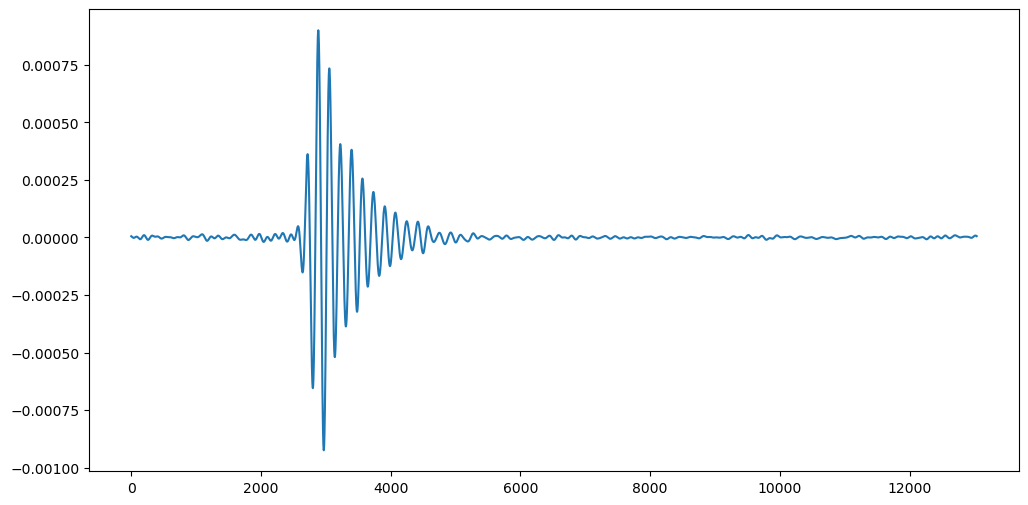

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(channel.get_trace())
plt.show()

In [18]:
reader0 = NuRadioRecoReader(det,filt_settings={"passband": [30 * units.MHz, 80 * units.MHz], "filter_type": "butter", "order": 10})
evt0 = reader0.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=0 * units.K)

WARNING - 2026-07-03 12:24:59,067 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:24:59,069 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:24:59,069 - NuRadioReco.detector - Cable delay not set for channel 1000002 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:24:59,070 - NuRadioReco.detector - Cable delay not set for channel 1000003 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:24:59,070 - NuRadioReco.detector - Cable delay not set for channel 1000004 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:24:59,071 - NuRadioReco.detector - Cable delay not set for channel 1000005 in station 1, assuming cable delay is zero
WARNING - 2026-07-03 12:24:59,071 - NuRadioReco.detector - Cable delay not set for channel 1000006 in station 1, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 12:25:00,903 - NuRadioReco.detector - Cable delay not set for channel 2000000 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:25:00,904 - NuRadioReco.detector - Cable delay not set for channel 2000001 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:25:00,905 - NuRadioReco.detector - Cable delay not set for channel 2000002 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:25:00,905 - NuRadioReco.detector - Cable delay not set for channel 2000003 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:25:00,905 - NuRadioReco.detector - Cable delay not set for channel 2000004 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:25:00,906 - NuRadioReco.detector - Cable delay not set for channel 2000005 in station 2, assuming cable delay is zero
WARNING - 2026-07-03 12:25:00,906 - NuRadioReco.detector - Cable delay not set for channel 2000006 in station 2, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 12:25:02,556 - NuRadioReco.detector - Cable delay not set for channel 3000000 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:25:02,556 - NuRadioReco.detector - Cable delay not set for channel 3000001 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:25:02,557 - NuRadioReco.detector - Cable delay not set for channel 3000002 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:25:02,557 - NuRadioReco.detector - Cable delay not set for channel 3000003 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:25:02,558 - NuRadioReco.detector - Cable delay not set for channel 3000004 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:25:02,558 - NuRadioReco.detector - Cable delay not set for channel 3000005 in station 3, assuming cable delay is zero
WARNING - 2026-07-03 12:25:02,559 - NuRadioReco.detector - Cable delay not set for channel 3000006 in station 3, assuming cable delay is zero
WARNIN

...

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 12:25:07,151 - NuRadioReco.detector - Cable delay not set for channel 6000000 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:25:07,151 - NuRadioReco.detector - Cable delay not set for channel 6000001 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:25:07,152 - NuRadioReco.detector - Cable delay not set for channel 6000002 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:25:07,153 - NuRadioReco.detector - Cable delay not set for channel 6000003 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:25:07,153 - NuRadioReco.detector - Cable delay not set for channel 6000004 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:25:07,153 - NuRadioReco.detector - Cable delay not set for channel 6000005 in station 6, assuming cable delay is zero
WARNING - 2026-07-03 12:25:07,154 - NuRadioReco.detector - Cable delay not set for channel 6000006 in station 6, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-07-03 12:25:08,050 - NuRadioReco.detector - Cable delay not set for channel 7010081 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:25:08,050 - NuRadioReco.detector - Cable delay not set for channel 7010082 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:25:08,051 - NuRadioReco.detector - Cable delay not set for channel 7010083 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:25:08,051 - NuRadioReco.detector - Cable delay not set for channel 7010084 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:25:08,052 - NuRadioReco.detector - Cable delay not set for channel 7010085 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:25:08,052 - NuRadioReco.detector - Cable delay not set for channel 7010086 in station 7, assuming cable delay is zero
WARNING - 2026-07-03 12:25:08,053 - NuRadioReco.detector - Cable delay not set for channel 7010087 in station 7, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


In [19]:
st0 = evt0.get_station(2)
chan0 = st0.get_channel(2004032)

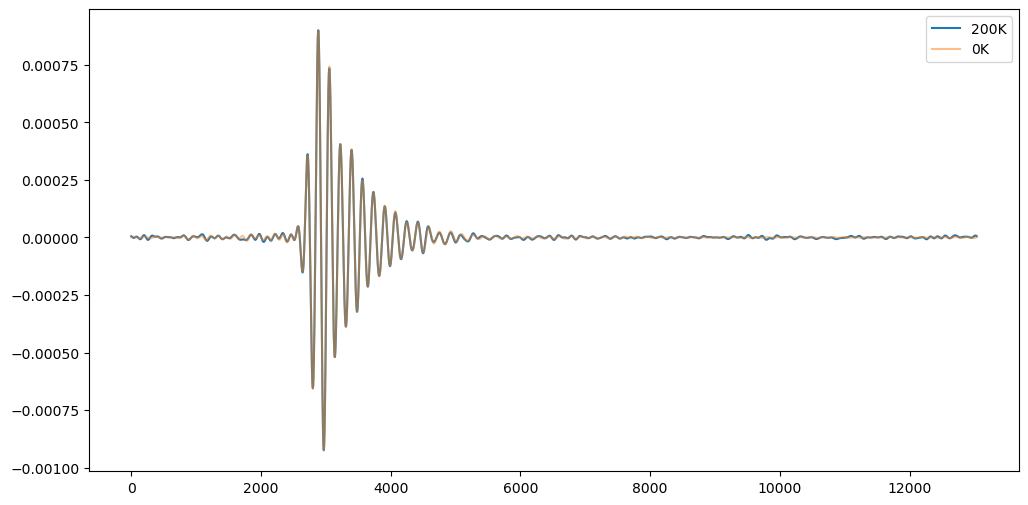

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(channel.get_trace(), label="200K")
plt.plot(chan0.get_trace(), label="0K", alpha=0.5)
plt.legend()
plt.show()